In [6]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, analyze_sys, tf2sos_analog

from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS

[-0.11932228+1.01949544j -0.11932228-1.01949544j -0.31238979+0.63008283j
 -0.31238979-0.63008283j -0.38613502+0.j        ]


(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

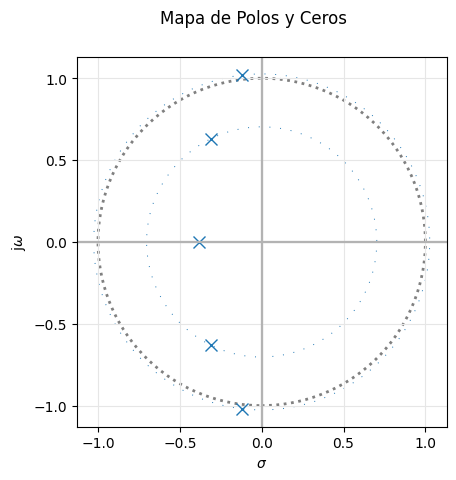

In [8]:
alfMax = 0.4

order = 5

# Para obtener la función transferencia del Cheby vía código directamente
# z,p,k = sig.cheb1ap(order, alfMax)
# num, den = sig.zpk2tf(z,p,k)

# Este vez lo voy a hacer de forma manual


eps = np.sqrt( 10**(alfMax/10) - 1 )   # 0.3106093948083108

# Construyo |T|²
numsq = np.sqrt(1/256/ eps**2)
den = np.array([1, 0, 640/256, 0, 560/256, 0, 200/256, 0 , 25/256, 0 , -1/256/ eps**2])
Tsq = TransferFunction(numsq, den)   

#pzmap(Tsq)

# Contruyo la transferencia Cheby
num = np.sqrt(1/256/ eps**2)
roots = np.roots(den)
roots = roots[ np.real(roots) < 0 ]   # filtro los polos del semiplano derecho
den = np.poly(roots)
T = TransferFunction(num, den)

print(roots)

pzmap(T)

#print_latex(a_equal_b_latex_s('T(s)', T))



In [42]:
poles1 = np.array([
    -0.11932228 + 1.01949544j,
    -0.11932228 - 1.01949544j
])

poles2 = np.array([
    -0.31238979 + 0.63008283j,
    -0.31238979 - 0.63008283j
])

poles3 = np.array([
    -0.38613502+0.j
])

zeros = [] 

num1, den1 = sig.zpk2tf(zeros, poles1, 1)
num2, den2 = sig.zpk2tf(zeros, poles2, 1)
num3, den3 = sig.zpk2tf(zeros, poles3, 1)

# Fijo los numeradores para 0dB
num1 = den1[2]
num2 = den2[2]
num3 = den3[1]

# Contruyo las expresiones
num1_expr = num1
den1_expr = s**2 + s*den1[1] + den1[2]
num2_expr = num2
den2_expr = s**2 + s*den2[1] + den2[2]
num3_expr = num3
den3_expr = s + den3[1]

T1_expr = num1_expr / den1_expr
T2_expr = num2_expr / den2_expr
T3_expr = num3_expr / den3_expr

print_latex(a_equal_b_latex_s('T1(s)', T1_expr))
print_latex(a_equal_b_latex_s('T2(s)', T2_expr))
print_latex(a_equal_b_latex_s('T3(s)', T3_expr))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

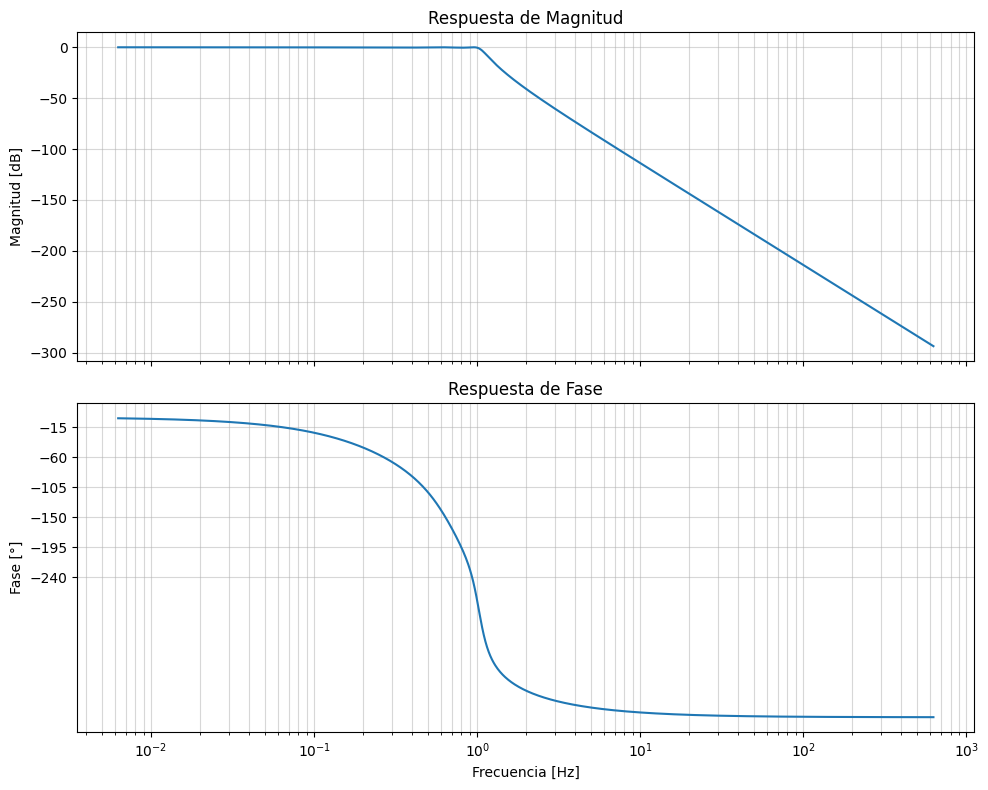

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

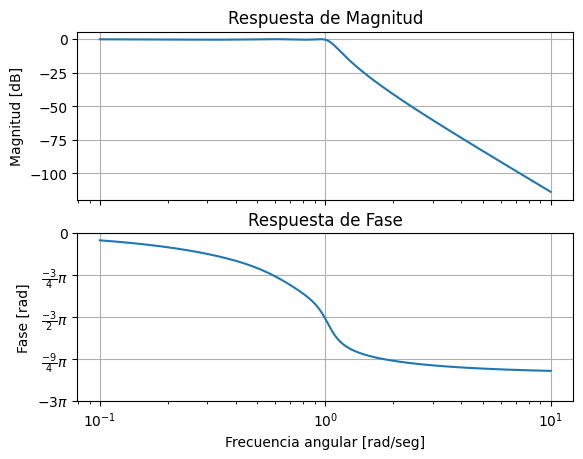

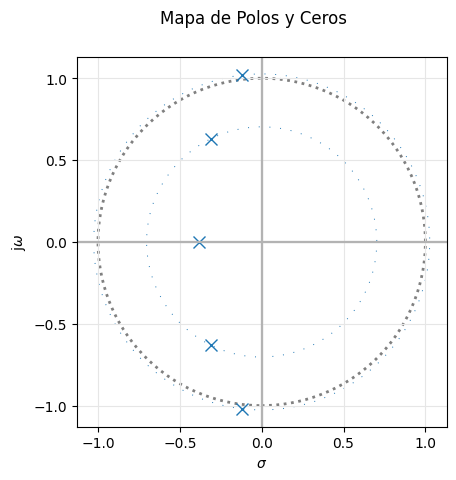

In [3]:
f = np.logspace(-3, 2, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-240, 181, 45)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia [Hz]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

# bodePlot(T)
pzmap(T)

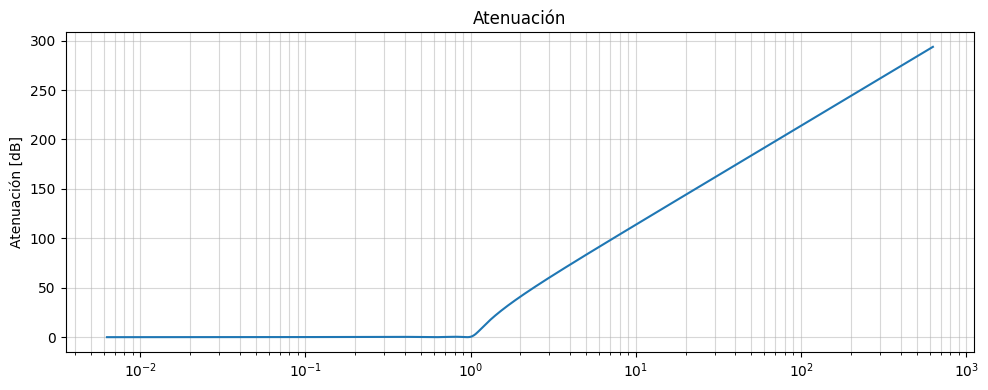

In [5]:
attenuation_db = -mag

fig, (ax_mag) = plt.subplots(figsize=(10, 4), sharex=True)


# Gráfico de Atenuación
ax_mag.semilogx(w, attenuation_db)
ax_mag.set_title('Atenuación')
ax_mag.set_ylabel('Atenuación [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()